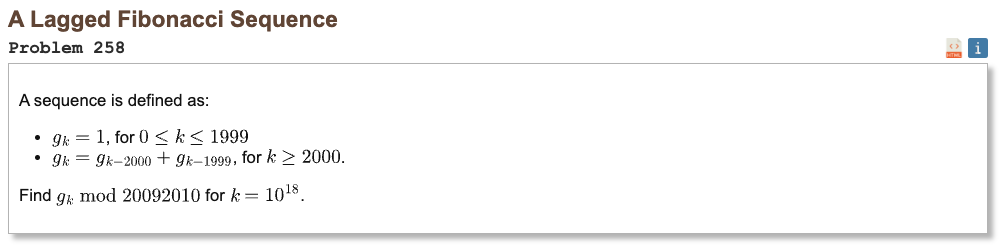

## Initial approach

* the recurrence is linear and depends on earlier terms
* rewrite it as a linear recurrence of fixed order
* represent the recurrence as a matrix transformation
* compute the power of that matrix using fast exponentiation
* multiply by the initial state vector
* take everything modulo the required modulus
* extract the requested term and print it

In [1]:
MOD = 10**9

def mat_mult(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    for i in range(n):
        for k in range(n):
            if A[i][k] == 0:
                continue
            for j in range(n):
                C[i][j] = (C[i][j] + A[i][k] * B[k][j]) % MOD
    return C

def mat_pow(M, power):
    n = len(M)
    result = [[0] * n for _ in range(n)]
    for i in range(n):
        result[i][i] = 1
    while power > 0:
        if power % 2 == 1:
            result = mat_mult(result, M)
        M = mat_mult(M, M)
        power //= 2
    return result

def solve():
    k = 2000
    N = 10**18

    if N <= k:
        print("Result:", 1)
        return

    M = [[0] * k for _ in range(k)]
    for i in range(k - 1):
        M[i][i + 1] = 1
    M[k - 1][0] = 1
    M[k - 1][k - 1] = 1

    P = mat_pow(M, N - k)

    init = [1] * k

    result = 0
    for i in range(k):
        result = (result + P[k - 1][i] * init[i]) % MOD

    print("Result:", result)

Note: performance optimization will follow.